# Model Comparison: Blog Search Agent Event Coverage & Cost

Compare event detection quality and cost across model configurations:
- **Baseline**: Claude Opus 4.6 across all swap points (assumed to detect all actual events)
- **Challenger 1**: GLM 5 across all swap points
- **Challenger 2**: Haiku 4.5 across all swap points
- **Challenger 3**: Nova 2 Lite across all swap points
- **Current Default**: Sonnet 4.6 (agent) + Nova 2 Lite (RSS) + Haiku 4.5 (web)

Kimi K2.5 blocked by SCP. Qwen VL 235B was not able to call the web search tool, seemed to be a model capability issue.

In [1]:
#!pip install requests boto3 feedparser pydantic python-dotenv strands-agents mcp pandas matplotlib


In [2]:
import sys
from pathlib import Path

EVAL_DIR = Path.cwd() if Path.cwd().name == "evaluation" else Path.cwd() / "evaluation"
ROOT = EVAL_DIR.parent

sys.path.insert(0, str(EVAL_DIR))
sys.path.insert(0, str(ROOT / "blog_search"))

from scripts.registry_sampler import sample_teams
from scripts.runner import run_evaluation, RESULTS_DIR
from scripts.comparator import compare_runs
from scripts.pricing import MODEL_CONFIGS, compute_cost_breakdown

## 1. Configuration

In [3]:
teams_data = sample_teams(n=2, seed=42)
team_names = [t["team"] for t in teams_data]

print("Selected teams:")
for t in teams_data:
    print(f"  {t['team']} — {len(t['blogs'])} blog(s)")
    for b in t["blogs"]:
        print(f"    - {b['url']} (RSS: {bool(b.get('rss_url'))})")

LOOKBACK_HOURS = 168
REFERENCE_DATE = ""  # Leave empty for current time, or set e.g. "2026-08-04"

Selected teams:
  UT Arlington Mavericks — 1 blog(s)
    - https://therustymaverick.com/ (RSS: True)
  Columbia Lions — 4 blog(s)
    - https://gocolumbialions.com/sports/mens-basketball (RSS: True)
    - https://www.columbiaspectator.com/sports/mens-basketball/ (RSS: False)
    - https://ivyleague.chat/ (RSS: False)
    - http://boston.alumni.columbia.edu/men_s_basketball (RSS: False)


## 2. Run Baseline — Claude Opus 4.6

In [4]:
baseline_result = await run_evaluation(
    teams=team_names,
    model_config=MODEL_CONFIGS["baseline_opus"],
    lookback_hours=LOOKBACK_HOURS,
    reference_date=REFERENCE_DATE,
)
print(f"\nBaseline: {baseline_result['totals']['events']} events, ${baseline_result['totals']['cost_usd']:.4f}")

  Running: UT Arlington Mavericks with Claude Opus 4.6...
    -> 0 events, 0.0s, agent tokens: 0in/0out
  Running: Columbia Lions with Claude Opus 4.6...
    -> 0 events, 21.31s, agent tokens: 7298in/899out
  Saved: /Users/priyashree.roy.ext/Documents/ncaa-blog-agent/evaluation/results/baseline_opus_20260805_122447.json

Baseline: 0 events, $0.0834


## 3. Run Challenger 1 — GLM 5

In [5]:
glm_result = await run_evaluation(
    teams=team_names,
    model_config=MODEL_CONFIGS["challenger_glm"],
    lookback_hours=LOOKBACK_HOURS,
    reference_date=REFERENCE_DATE,
)
print(f"\nGLM 5: {glm_result['totals']['events']} events, ${glm_result['totals']['cost_usd']:.4f}")

  Running: UT Arlington Mavericks with GLM 5...
    -> 0 events, 0.0s, agent tokens: 0in/0out
  Running: Columbia Lions with GLM 5...
    -> 0 events, 10.22s, agent tokens: 5022in/530out
  Saved: /Users/priyashree.roy.ext/Documents/ncaa-blog-agent/evaluation/results/challenger_glm_20260805_122509.json

GLM 5: 0 events, $0.0121


## 4. Run Challenger 2 — Haiku 4.5

In [6]:
haiku_result = await run_evaluation(
    teams=team_names,
    model_config=MODEL_CONFIGS["challenger_haiku"],
    lookback_hours=LOOKBACK_HOURS,
    reference_date=REFERENCE_DATE,
)
print(f"\nHaiku 4.5: {haiku_result['totals']['events']} events, ${haiku_result['totals']['cost_usd']:.4f}")

  Running: UT Arlington Mavericks with Haiku 4.5...
    -> 0 events, 0.0s, agent tokens: 0in/0out
  Running: Columbia Lions with Haiku 4.5...
    -> 0 events, 7.27s, agent tokens: 4430in/636out
  Saved: /Users/priyashree.roy.ext/Documents/ncaa-blog-agent/evaluation/results/challenger_haiku_20260805_122520.json

Haiku 4.5: 0 events, $0.0113


## 5. Run Challenger 3 — Nova 2 Lite

In [7]:
nova_result = await run_evaluation(
    teams=team_names,
    model_config=MODEL_CONFIGS["challenger_nova"],
    lookback_hours=LOOKBACK_HOURS,
    reference_date=REFERENCE_DATE,
)
print(f"\nNova 2 Lite: {nova_result['totals']['events']} events, ${nova_result['totals']['cost_usd']:.4f}")

  Running: UT Arlington Mavericks with Nova 2 Lite...
    -> 0 events, 0.0s, agent tokens: 0in/0out
  Running: Columbia Lions with Nova 2 Lite...
    -> 0 events, 4.56s, agent tokens: 4598in/403out
  Saved: /Users/priyashree.roy.ext/Documents/ncaa-blog-agent/evaluation/results/challenger_nova_20260805_122527.json

Nova 2 Lite: 0 events, $0.0035


## 6. Run Current Default — Sonnet 4.6 + Nova Lite + Haiku 4.5

In [8]:
default_result = await run_evaluation(
    teams=team_names,
    model_config=MODEL_CONFIGS["current_default"],
    lookback_hours=LOOKBACK_HOURS,
    reference_date=REFERENCE_DATE,
)
print(f"\nDefault: {default_result['totals']['events']} events, ${default_result['totals']['cost_usd']:.4f}")

  Running: UT Arlington Mavericks with Sonnet 4.6 + Nova Lite + Haiku 4.5...
    -> 0 events, 0.0s, agent tokens: 0in/0out
  Running: Columbia Lions with Sonnet 4.6 + Nova Lite + Haiku 4.5...
    -> 0 events, 15.31s, agent tokens: 7230in/862out
  Saved: /Users/priyashree.roy.ext/Documents/ncaa-blog-agent/evaluation/results/current_default_20260805_122532.json

Default: 0 events, $0.0387


## 7. Coverage Comparison

In [9]:
import pandas as pd

glm_comparison = compare_runs(baseline_result, glm_result)
haiku_comparison = compare_runs(baseline_result, haiku_result)
nova_comparison = compare_runs(baseline_result, nova_result)
default_comparison = compare_runs(baseline_result, default_result)

all_runs = [
    ("Claude Opus 4.6 (baseline)", baseline_result, None),
    ("GLM 5", glm_result, glm_comparison),
    ("Haiku 4.5", haiku_result, haiku_comparison),
    ("Nova 2 Lite", nova_result, nova_comparison),
    ("Sonnet + Nova + Haiku", default_result, default_comparison),
]

n_teams = len(team_names)

summary_data = []
for label, result, comparison in all_runs:
    recall = comparison["aggregate"]["recall_vs_baseline"] if comparison else 1.0
    summary_data.append({
        "Model": label,
        "Events Found": result["totals"]["events"],
        "Recall vs Baseline": f"{recall:.1%}",
        "Total Web Searches": result["totals"]["web_searches"],
        "Avg Web Searches/Team": f"{result['totals']['web_searches'] / n_teams:.1f}",
        "Cost (USD)": f"${result['totals']['cost_usd']:.4f}",
    })

pd.DataFrame(summary_data)

,Model,Events Found,Recall vs Baseline,Total Web Searches,Avg Web Searches/Team,Cost (USD)
0,Claude Opus 4.6 (baseline),0,100.0%,0,0.0,$0.0834
1,GLM 5,0,100.0%,0,0.0,$0.0121
2,Haiku 4.5,0,100.0%,0,0.0,$0.0113
3,Nova 2 Lite,0,100.0%,0,0.0,$0.0035
4,Sonnet + Nova + Haiku,0,100.0%,0,0.0,$0.0387


In [10]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Opus 4.6\n(baseline)", "GLM 5", "Haiku 4.5", "Nova 2\nLite", "Sonnet+Nova\n+Haiku"]
results_list = [baseline_result, glm_result, haiku_result, nova_result, default_result]
comparisons = [None, glm_comparison, haiku_comparison, nova_comparison, default_comparison]
colors = ["#4A90D9", "#E67E22", "#27AE60", "#8E44AD", "#E74C3C"]

# Compute cost breakdown per run
breakdowns = []
for result in results_list:
    token_keys = ["agent_input_tokens", "agent_output_tokens",
                  "rss_input_tokens", "rss_output_tokens",
                  "web_input_tokens", "web_output_tokens"]
    totals = {k: 0 for k in token_keys}
    for r in result["team_results"]:
        for k in token_keys:
            totals[k] += r["token_usage"][k]
    bd = compute_cost_breakdown(
        result["model_config"], totals, result["totals"]["web_searches"]
    )
    breakdowns.append(bd)

## 8. Cost Breakdown: Web Search API vs LLM Extraction

Costs are split into:
- **Web Search API**: $7 per 1,000 queries (gateway__WebSearch tool calls)
- **Agent LLM**: Strands orchestrator model (reasoning + tool selection)
- **RSS Extraction LLM**: Model that extracts events from RSS feed content
- **Web Extraction LLM**: Model that extracts events from web-fetched page content

In [11]:
# Cost breakdown table per team
cost_data = []
for label, result, bd in zip(
    [r[0] for r in all_runs], results_list, breakdowns
):
    total = bd["total"]
    web_searches = result["totals"]["web_searches"]
    cost_data.append({
        "Model": label,
        "Web Search API": f"${bd['web_search']:.4f}",
        "Agent LLM": f"${bd['agent_llm']:.4f}",
        "RSS Extraction LLM": f"${bd['rss_llm']:.4f}",
        "Web Extraction LLM": f"${bd['web_llm']:.4f}",
        "Total": f"${total:.4f}",
        "Cost/Team": f"${total / n_teams:.4f}",
    })

pd.DataFrame(cost_data)

,Model,Web Search API,Agent LLM,RSS Extraction LLM,Web Extraction LLM,Total,Cost/Team
0,Claude Opus 4.6 (baseline),$0.0000,$0.0590,$0.0058,$0.0186,$0.0834,$0.0417
1,GLM 5,$0.0000,$0.0067,$0.0011,$0.0043,$0.0121,$0.0061
2,Haiku 4.5,$0.0000,$0.0076,$0.0012,$0.0025,$0.0113,$0.0056
3,Nova 2 Lite,$0.0000,$0.0024,$0.0004,$0.0007,$0.0035,$0.0017
4,Sonnet + Nova + Haiku,$0.0000,$0.0346,$0.0004,$0.0038,$0.0387,$0.0194


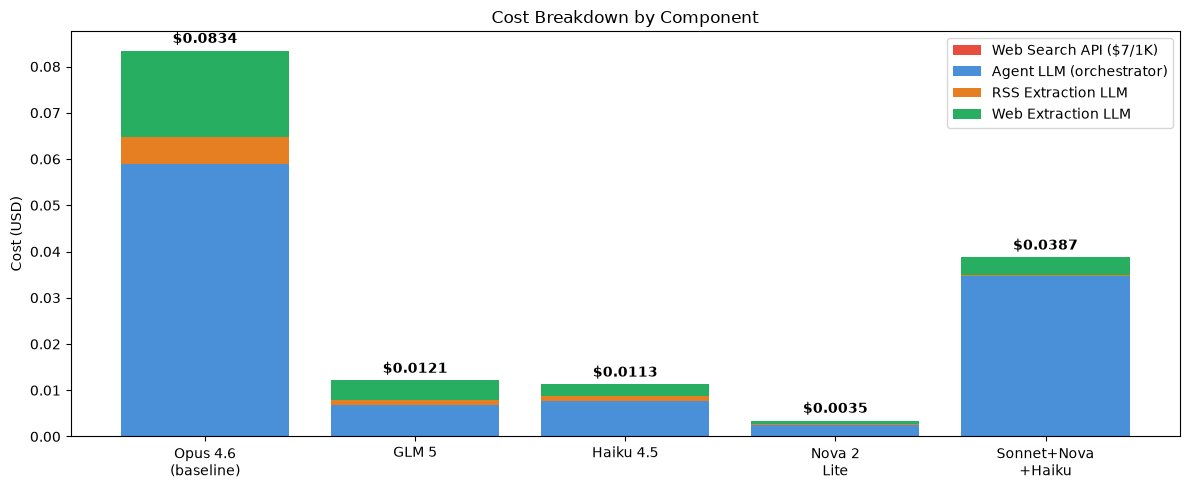

In [12]:
# Stacked bar: 4-component cost breakdown
fig, ax = plt.subplots(figsize=(12, 5))

web_search_costs = [bd["web_search"] for bd in breakdowns]
agent_costs = [bd["agent_llm"] for bd in breakdowns]
rss_costs = [bd["rss_llm"] for bd in breakdowns]
web_extract_costs = [bd["web_llm"] for bd in breakdowns]

x = np.arange(len(models))
bottom = np.zeros(len(models))

ax.bar(x, web_search_costs, label="Web Search API ($7/1K)", color="#E74C3C", bottom=bottom)
bottom += web_search_costs
ax.bar(x, agent_costs, label="Agent LLM (orchestrator)", color="#4A90D9", bottom=bottom)
bottom += agent_costs
ax.bar(x, rss_costs, label="RSS Extraction LLM", color="#E67E22", bottom=bottom)
bottom += rss_costs
ax.bar(x, web_extract_costs, label="Web Extraction LLM", color="#27AE60", bottom=bottom)

ax.set_ylabel("Cost (USD)")
ax.set_title("Cost Breakdown by Component")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc="upper right")

totals = [bd["total"] for bd in breakdowns]
for i, t in enumerate(totals):
    ax.text(i, t + max(totals) * 0.02, f"${t:.4f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 9. Average Cost per Team & Event Coverage

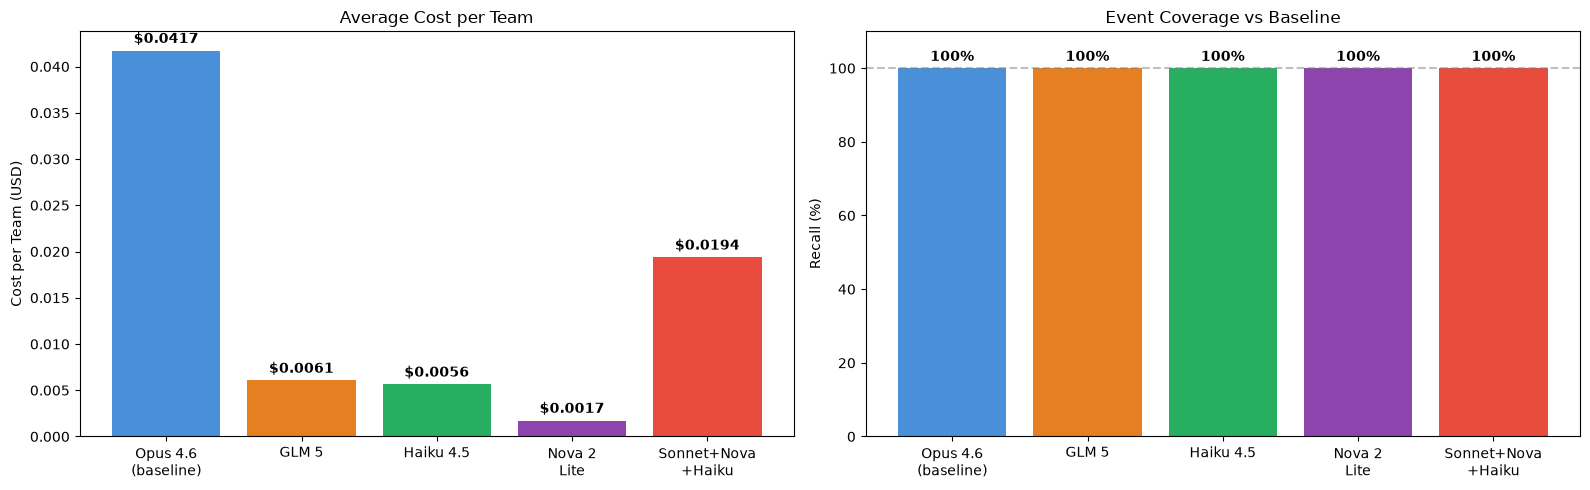

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Avg Cost per Team
avg_costs = [bd["total"] / n_teams for bd in breakdowns]
axes[0].bar(models, avg_costs, color=colors)
axes[0].set_ylabel("Cost per Team (USD)")
axes[0].set_title("Average Cost per Team")
for i, v in enumerate(avg_costs):
    axes[0].text(i, v + max(avg_costs) * 0.02, f"${v:.4f}", ha="center", fontweight="bold")

# Recall vs Baseline
recalls = [c["aggregate"]["recall_vs_baseline"] if c else 1.0 for c in comparisons]
axes[1].bar(models, [r * 100 for r in recalls], color=colors)
axes[1].set_title("Event Coverage vs Baseline")
axes[1].set_ylabel("Recall (%)")
axes[1].set_ylim(0, 110)
axes[1].axhline(y=100, color="gray", linestyle="--", alpha=0.5)
for i, v in enumerate(recalls):
    axes[1].text(i, v * 100 + 2, f"{v:.0%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "model_comparison_charts.png"), dpi=150, bbox_inches="tight")
plt.show()

## 10. Per-Team Breakdown

In [14]:
team_data = []
for result in results_list:
    for tr in result["team_results"]:
        tu = tr["token_usage"]
        team_data.append({
            "Model": result["model_config"]["label"],
            "Team": tr["team"],
            "Events": tr["events_count"],
            "Web Searches": tr["web_searches"],
            "Web Fetches": tr["web_fetches"],
            "RSS Feeds": tr["rss_feeds_fetched"],
            "Agent Tokens (in/out)": f"{tu['agent_input_tokens']}/{tu['agent_output_tokens']}",
            "RSS Extract Tokens (in/out)": f"{tu['rss_input_tokens']}/{tu['rss_output_tokens']}",
            "Web Extract Tokens (in/out)": f"{tu['web_input_tokens']}/{tu['web_output_tokens']}",
            "Latency (s)": tr["latency_seconds"],
        })

pd.DataFrame(team_data)

,Model,Team,Events,Web Searches,Web Fetches,RSS Feeds,Agent Tokens (in/out),RSS Extract Tokens (in/out),Web Extract Tokens (in/out),Latency (s)
0,Claude Opus 4.6,UT Arlington Mavericks,0,0,0,0,0/0,0/0,0/0,0.00
1,Claude Opus 4.6,Columbia Lions,0,0,3,1,7298/899,1095/14,3475/51,21.31
2,GLM 5,UT Arlington Mavericks,0,0,0,0,0/0,0/0,0/0,0.00
3,GLM 5,Columbia Lions,0,0,4,1,5022/530,1095/14,4108/48,10.22
4,Haiku 4.5,UT Arlington Mavericks,0,0,0,0,0/0,0/0,0/0,0.00
5,Haiku 4.5,Columbia Lions,0,0,2,1,4430/636,1095/14,2336/34,7.27
6,Nova 2 Lite,UT Arlington Mavericks,0,0,0,0,0/0,0/0,0/0,0.00
7,Nova 2 Lite,Columbia Lions,0,0,2,1,4598/403,1095/14,2115/28,4.56
8,Sonnet 4.6 + Nova Lite + Haiku 4.5,UT Arlington Mavericks,0,0,0,0,0/0,0/0,0/0,0.00
9,Sonnet 4.6 + Nova Lite + Haiku 4.5,Columbia Lions,0,0,3,1,7230/862,1095/14,3507/51,15.31


## 11. Token Usage by Component

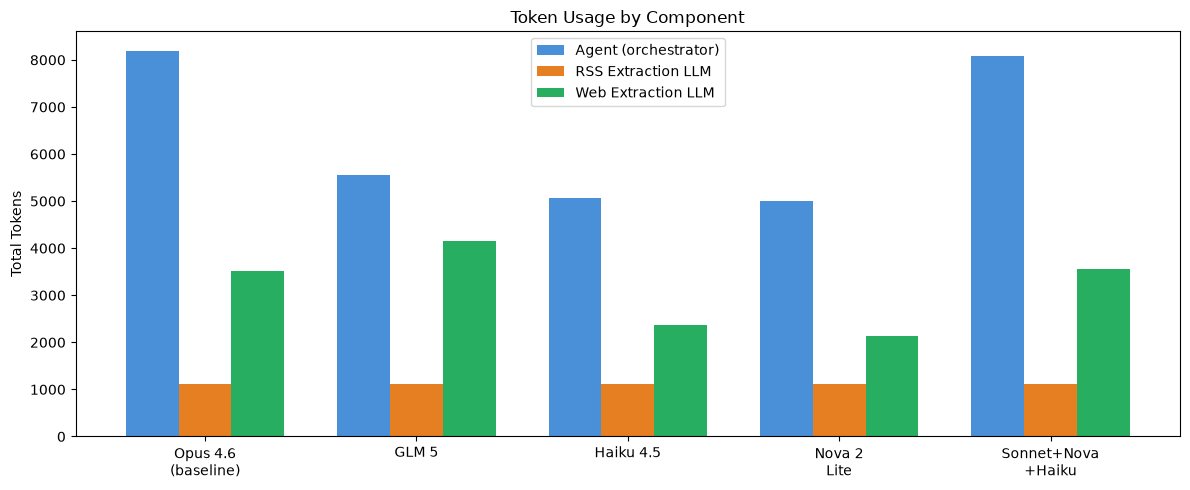

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(models))
width = 0.25

agent_tok = [
    sum(r["token_usage"]["agent_input_tokens"] + r["token_usage"]["agent_output_tokens"]
        for r in res["team_results"])
    for res in results_list
]
rss_tok = [
    sum(r["token_usage"]["rss_input_tokens"] + r["token_usage"]["rss_output_tokens"]
        for r in res["team_results"])
    for res in results_list
]
web_extract_tok = [
    sum(r["token_usage"]["web_input_tokens"] + r["token_usage"]["web_output_tokens"]
        for r in res["team_results"])
    for res in results_list
]

ax.bar(x - width, agent_tok, width, label="Agent (orchestrator)", color="#4A90D9")
ax.bar(x, rss_tok, width, label="RSS Extraction LLM", color="#E67E22")
ax.bar(x + width, web_extract_tok, width, label="Web Extraction LLM", color="#27AE60")
ax.set_ylabel("Total Tokens")
ax.set_title("Token Usage by Component")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

plt.tight_layout()
plt.show()

## 12. Cost Efficiency Summary

In [16]:
baseline_cost = baseline_result["totals"]["cost_usd"]

efficiency_data = []
for (label, result, comparison), bd in zip(all_runs, breakdowns):
    cost = bd["total"]
    recall = comparison["aggregate"]["recall_vs_baseline"] if comparison else 1.0
    events = result["totals"]["events"]
    web_searches = result["totals"]["web_searches"]
    web_fetches = sum(r["web_fetches"] for r in result["team_results"])
    savings = ((baseline_cost - cost) / baseline_cost * 100) if baseline_cost > 0 else 0

    efficiency_data.append({
        "Model": label,
        "Events": events,
        "Recall": f"{recall:.1%}",
        "Cost/Team": f"${cost / n_teams:.4f}",
        "Web Searches": web_searches,
        "Web Fetches": web_fetches,
        "% Web Search API": f"{bd['web_search'] / cost * 100:.0f}%" if cost > 0 else "—",
        "% Agent LLM": f"{bd['agent_llm'] / cost * 100:.0f}%" if cost > 0 else "—",
        "% RSS Extract": f"{bd['rss_llm'] / cost * 100:.0f}%" if cost > 0 else "—",
        "% Web Extract": f"{bd['web_llm'] / cost * 100:.0f}%" if cost > 0 else "—",
        "Savings vs Baseline": f"{savings:.1f}%",
    })

pd.DataFrame(efficiency_data)

,Model,Events,Recall,Cost/Team,Web Searches,Web Fetches,% Web Search API,% Agent LLM,% RSS Extract,% Web Extract,Savings vs Baseline
0,Claude Opus 4.6 (baseline),0,100.0%,$0.0417,0,3,0%,71%,7%,22%,-0.0%
1,GLM 5,0,100.0%,$0.0061,0,4,0%,55%,9%,35%,85.5%
2,Haiku 4.5,0,100.0%,$0.0056,0,2,0%,67%,10%,22%,86.5%
3,Nova 2 Lite,0,100.0%,$0.0017,0,2,0%,69%,11%,20%,95.9%
4,Sonnet + Nova + Haiku,0,100.0%,$0.0194,0,3,0%,89%,1%,10%,53.5%
